#***MOUNT DRIVE***

In [65]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


BASE_DIR: True
CLASS_MODEL: True
SEG_MODEL: True
TEST_DIR: True
Loading models...
Models loaded
Head layers found: ['global_average_pooling2d_1', 'batch_normalization_1', 'dense_2', 'dropout_1', 'dense_3']

Processing: test_glioma.jpg
Prediction: glioma Confidence: 0.9657498


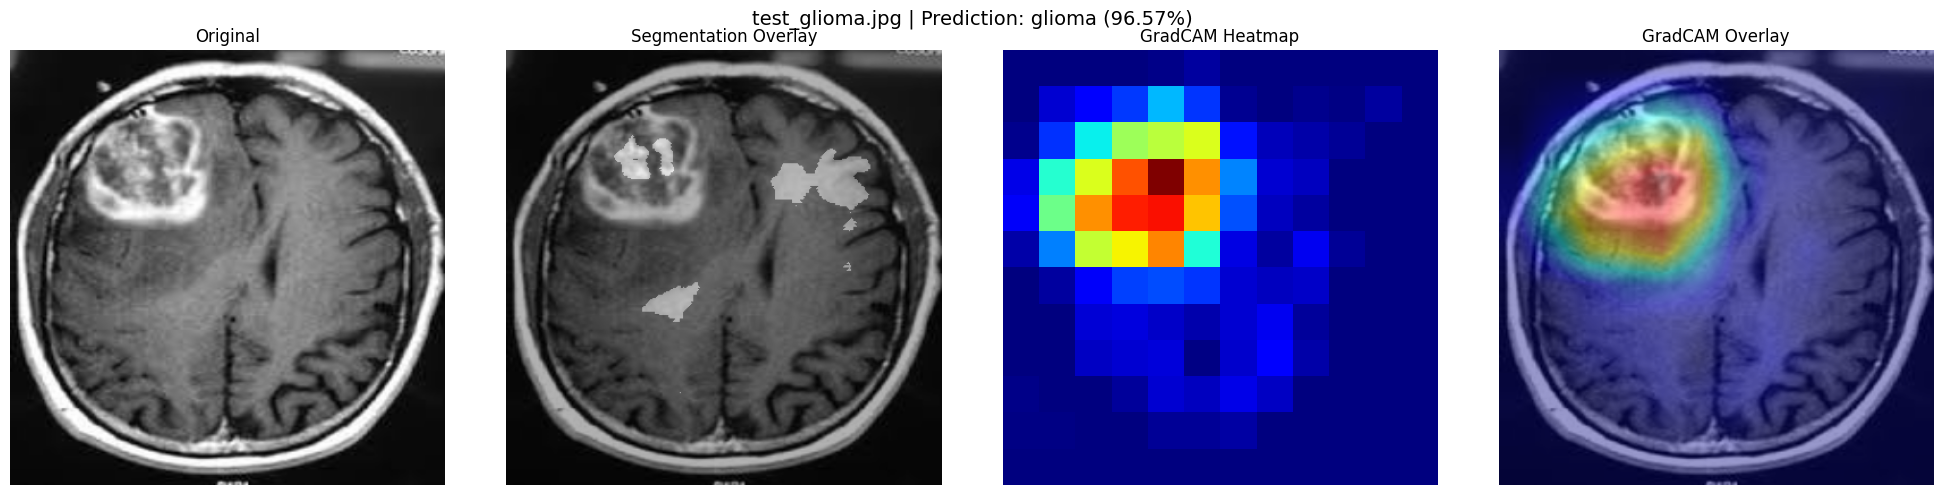


Processing: test_meningioma.jpg
Prediction: meningioma Confidence: 0.89438844


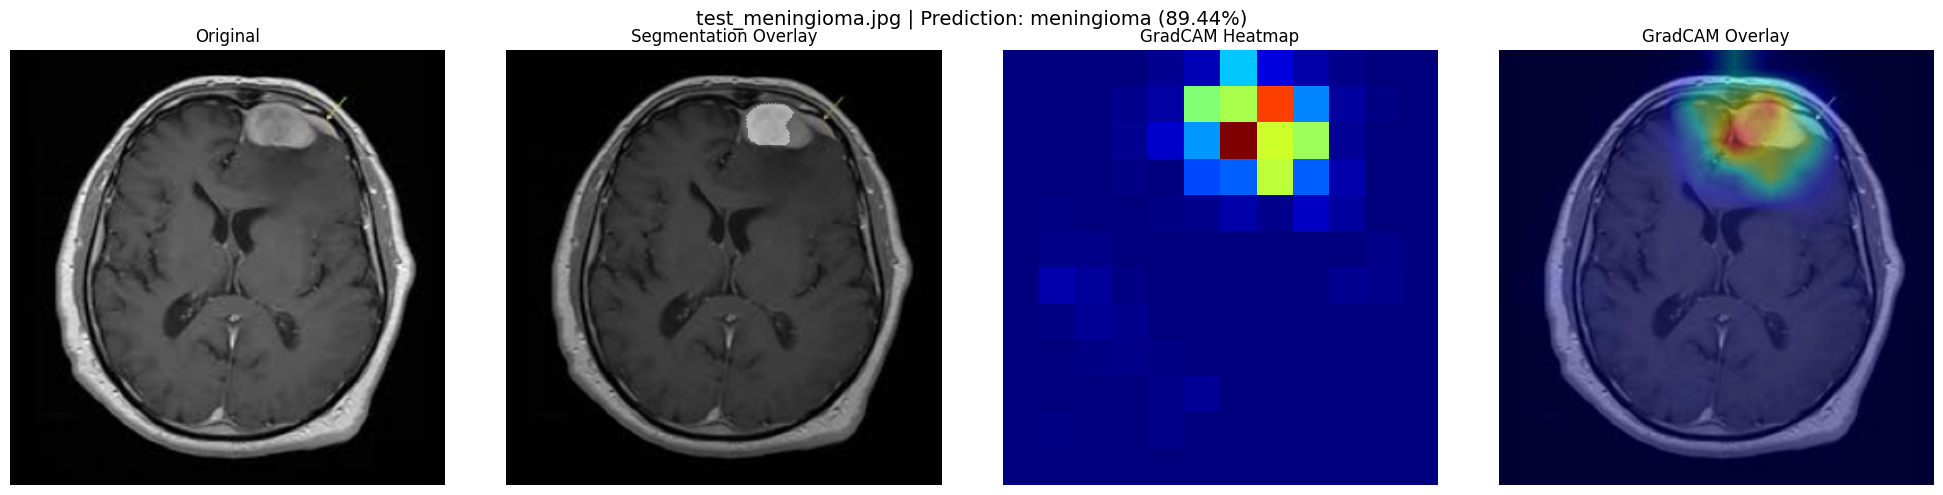


Processing: test_pituitary.jpg
Prediction: pituitary Confidence: 0.8575417


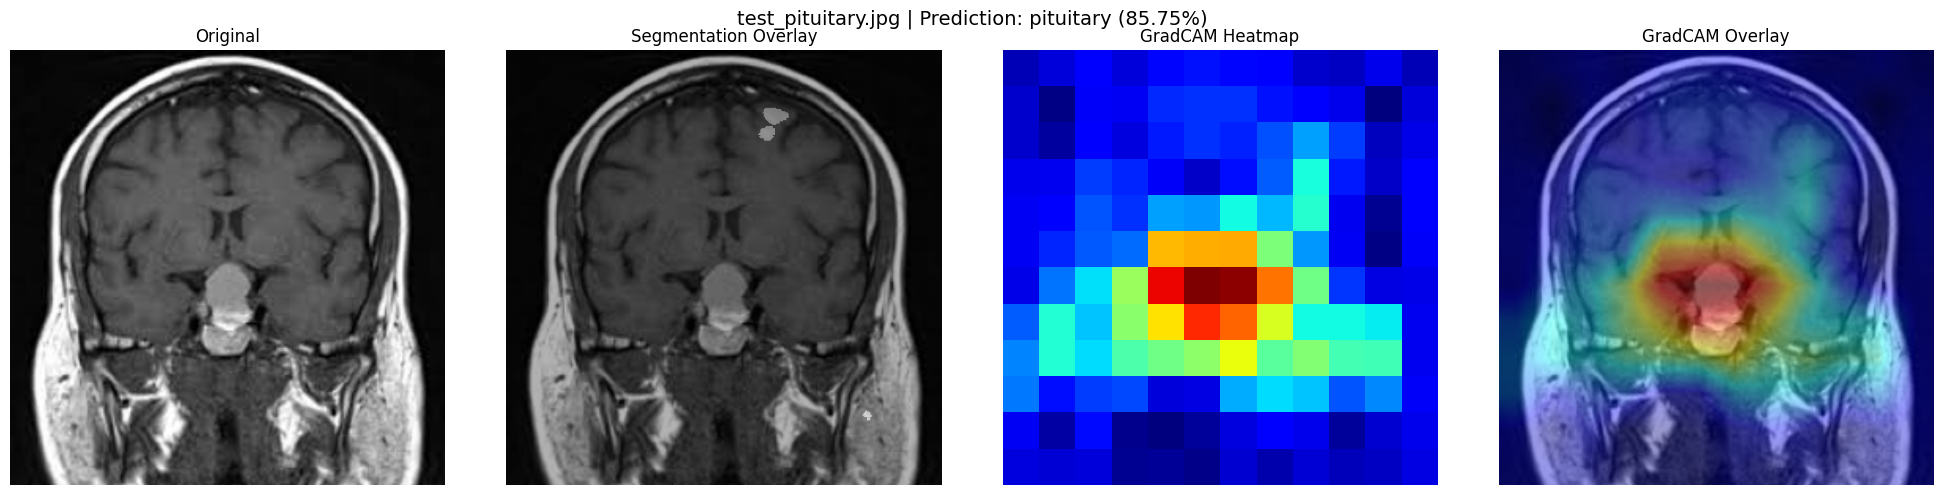


Processing: test_no tumor.jpg
Prediction: no_tumor Confidence: 0.9216859


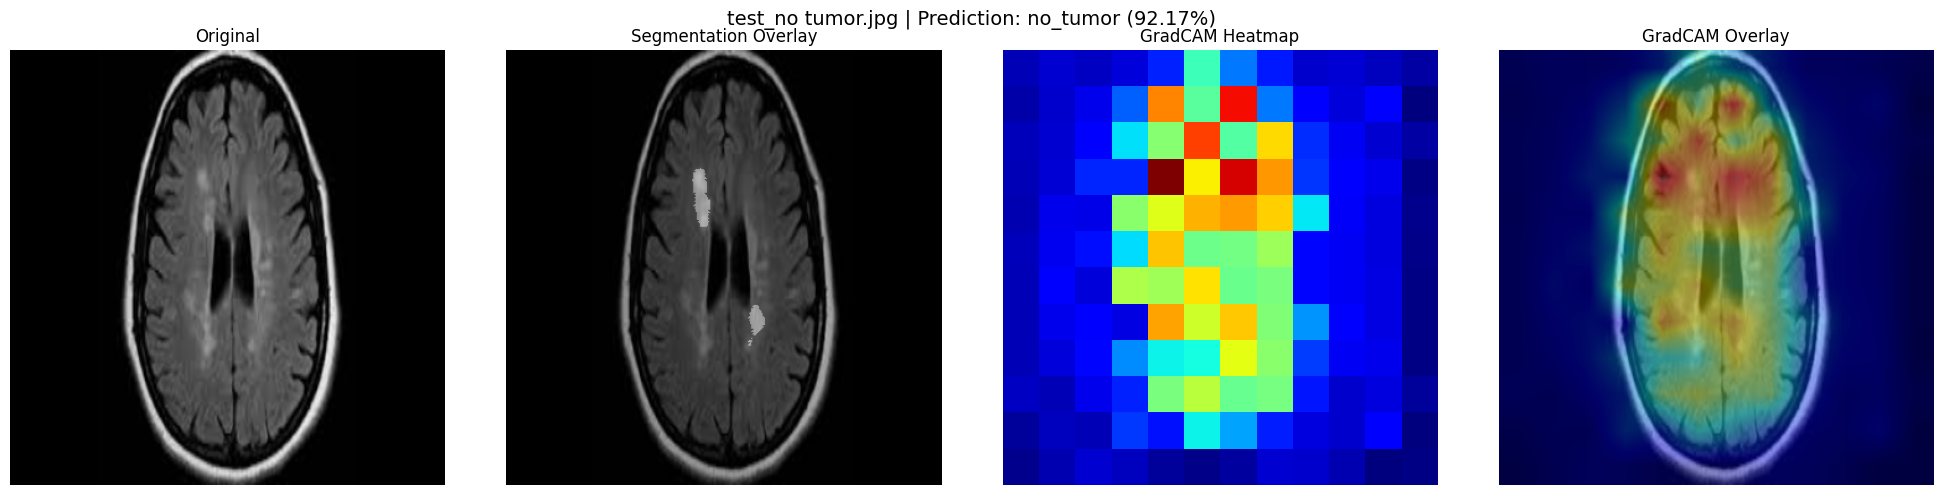

In [72]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as effv2_prep

# ========================================
# PATH CONFIGURATION
# ========================================
BASE_DIR = "/content/drive/MyDrive/Project work"
CLASS_MODEL_PATH = BASE_DIR + "/models/Classification/Tumor_v2s_clean.keras"
SEG_MODEL_PATH   = BASE_DIR + "/models/Segmentation/unet_lgg_segmentation_u-net.keras"
TEST_DIR = BASE_DIR + "/Test Data"

IMG_SIZE = 384
SEG_SIZE = 256

CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]

# ========================================
# VERIFY PATHS
# ========================================
print("BASE_DIR:", os.path.exists(BASE_DIR))
print("CLASS_MODEL:", os.path.exists(CLASS_MODEL_PATH))
print("SEG_MODEL:", os.path.exists(SEG_MODEL_PATH))
print("TEST_DIR:", os.path.exists(TEST_DIR))

# ========================================
# LOAD MODELS
# ========================================
print("Loading models...")
class_model = tf.keras.models.load_model(CLASS_MODEL_PATH)
seg_model   = tf.keras.models.load_model(SEG_MODEL_PATH, compile=False)
print("Models loaded")

# ========================================
# GRADCAM SETUP
# ========================================
base_model = class_model.get_layer("efficientnetv2-s")

# Get head layers (everything after base_model)
head_layers = []
reached = False
for layer in class_model.layers:
    if layer.name == "efficientnetv2-s":
        reached = True
        continue
    if reached:
        head_layers.append(layer)

print(f"Head layers found: {[l.name for l in head_layers]}")

# ========================================
# IMAGE LOADER
# ========================================
def load_class_image(path):
    img = tf.keras.utils.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    img = tf.keras.utils.img_to_array(img)
    img = effv2_prep(img)
    img = np.expand_dims(img, axis=0)
    return img

# ========================================
# GRADCAM FUNCTION
# ========================================
def get_gradcam_heatmap(img_tensor):
    img_tensor_cast = tf.cast(img_tensor, tf.float32)

    # Step 1: get conv output from base_model
    conv_output = base_model(img_tensor_cast, training=False)

    # Step 2: use tf.Variable so tape can track gradients through head
    conv_var = tf.Variable(conv_output)

    with tf.GradientTape() as tape:
        tape.watch(conv_var)
        x = conv_var
        for layer in head_layers:
            x = layer(x)
        predictions = x
        class_index = tf.argmax(predictions[0])
        class_score = predictions[:, class_index]

    grads = tape.gradient(class_score, conv_var)

    if grads is None:
        print("WARNING: grads is None, returning empty heatmap")
        return np.zeros((12, 12))

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_output[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# ========================================
# MAIN LOOP
# ========================================
for file in os.listdir(TEST_DIR):

    if not file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
        continue

    print("\nProcessing:", file)
    image_path = os.path.join(TEST_DIR, file)

    orig = cv2.imread(image_path)
    orig = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))

    img_class = load_class_image(image_path)
    img_tensor = tf.convert_to_tensor(img_class)

    preds = class_model(img_tensor, training=False)[0].numpy()
    class_id = np.argmax(preds)
    label = CLASS_NAMES[class_id]
    confidence = preds[class_id]
    print("Prediction:", label, "Confidence:", confidence)

    # Segmentation
    img_seg = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_seg = cv2.resize(img_seg, (SEG_SIZE, SEG_SIZE))
    img_seg = img_seg / 255.0
    img_seg = np.expand_dims(img_seg, (0, -1))

    mask = seg_model(img_seg, training=False)[0].numpy()
    mask = (mask > 0.5).astype(np.uint8)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

    mask_vis = np.uint8(mask * 255)
    mask_color = cv2.applyColorMap(mask_vis, cv2.COLORMAP_HOT)
    mask_overlay = cv2.addWeighted(orig, 0.7, mask_color, 0.3, 0)

    # GradCAM
    heatmap = get_gradcam_heatmap(img_tensor)

    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    gradcam_overlay = cv2.addWeighted(orig, 0.6, heatmap_color, 0.4, 0)

    # Display
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"{file} | Prediction: {label} ({confidence:.2%})", fontsize=14)

    axes[0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(cv2.cvtColor(mask_overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Segmentation Overlay")
    axes[1].axis("off")

    axes[2].imshow(heatmap, cmap="jet")
    axes[2].set_title("GradCAM Heatmap")
    axes[2].axis("off")

    axes[3].imshow(cv2.cvtColor(gradcam_overlay, cv2.COLOR_BGR2RGB))
    axes[3].set_title("GradCAM Overlay")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()